# Import essential libraries

In [1]:
import pandas as pd              
import numpy as np               
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Import dataset and info of it

In [2]:
data = pd.read_csv('t20.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2592 entries, 0 to 2591
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Match Format           2592 non-null   object
 1   Team1 Name             2592 non-null   object
 2   Team2 Name             2592 non-null   object
 3   Match Venue (Stadium)  2592 non-null   object
 4   Match Venue (Country)  2592 non-null   object
 5   Toss Winner            2592 non-null   object
 6   Toss Winner Choice     2592 non-null   object
 7   Match Winner           2592 non-null   object
 8   Team1 Runs Scored      2592 non-null   int64 
 9   Team1 Wickets Fell     2592 non-null   int64 
 10  Team2 Runs Scored      2592 non-null   int64 
 11  Team2 Wickets Fell     2592 non-null   int64 
dtypes: int64(4), object(8)
memory usage: 162.1+ KB


# Check whether how many counts of each components in 'Match Format'

In [4]:
choice_counts = data['Match Format'].value_counts()
choice_counts

Match Format
T20    2592
Name: count, dtype: int64

# Encode table data (teams names)

In [5]:
team_related_cols = ['Team1 Name', 'Team2 Name', 'Toss Winner', 'Match Winner', 'Match Venue (Country)']

# Combine all unique team names + countries (so mapping stays consistent)
unique_teams = pd.unique(data[team_related_cols].values.ravel())
print("✅ Unique team/country names found:\n", unique_teams)

# Fit a single encoder for all team/country names
team_encoder = LabelEncoder()
team_encoder.fit(unique_teams)

# Apply encoding (starting from 1 instead of 0)
for col in team_related_cols:
    data[col] = team_encoder.transform(data[col]) 

# Team name (and country) mapping
team_mapping = {team: code for team, code in zip(team_encoder.classes_, team_encoder.transform(team_encoder.classes_))}
print("\n🏏 Team/Country → Encoded Number Mapping:")
for team, code in team_mapping.items():
    print(f"{team} → {code}")

✅ Unique team/country names found:
 ['India' 'Australia' 'England' 'New Zealand' 'Scotland' 'Netherlands'
 'Ireland' 'Kenya' 'Zimbabwe' 'Sri Lanka' 'Canada' 'Pakistan'
 'South Africa' 'Bangladesh' 'West Indies' '0' 'Bermuda'
 'United Arab Emirates' 'Afghanistan' 'United States of America' 'Namibia'
 'Mozambique' 'Malawi' 'Nepal' 'Hong Kong' 'U.A.E.' 'P.N.G.' 'Oman'
 'World-XI' 'ICC World XI' 'Bahrain' 'Saudi Arabia' 'Maldives' 'Kuwait'
 'Qatar' 'U.S.A.' 'Philippines' 'Papua New Guinea' 'Vanuatu' 'Malta'
 'Spain' 'Mexico' 'Belize' 'Costa Rica' 'Panama' 'Germany' 'Belgium'
 'Nigeria' 'Uganda' 'Ghana' 'Botswana' 'Italy' 'Jersey' 'Guernsey'
 'Norway' 'Denmark' 'Thailand' 'Malaysia' 'Samoa' 'Finland' 'Singapore'
 'Cayman Is' 'Bulgaria' 'Serbia' 'Romania' 'Austria' 'Turkey' 'Luxembourg'
 'Czech Rep.' 'Argentina' 'Chile' 'Peru' 'Brazil' 'Greece' 'Portugal'
 'Gibraltar' 'Rwanda' 'Tanzania' 'Bhutan' 'Iran' 'Isle of Man'
 'Czech Republic' 'Sweden' 'France' 'Hungary' 'Estonia' 'Cyprus'
 'Swazilan

# Encode table data (ground)

In [6]:
ground_encoder = LabelEncoder()

data['Match Venue (Stadium)'] = ground_encoder.fit_transform(data['Match Venue (Stadium)'])

# Ground mapping
ground_mapping = {ground: code for ground, code in zip(ground_encoder.classes_, ground_encoder.transform(ground_encoder.classes_))}
print("\n Ground Encoded Number Mapping:")
for ground, code in ground_mapping.items():
    print(f"{ground} → {code}")


 Ground Encoded Number Mapping:
AMI Stadium → 0
AZ Group Cricket Oval → 1
Achimota Senior Secondary School A Field → 2
Achimota Senior Secondary School B Field → 3
Adelaide Oval → 4
Al Amerat Cricket Ground Oman Cricket (Ministry Turf 1) → 5
Al Amerat Cricket Ground Oman Cricket (Ministry Turf 2) → 6
Albert Park 1 → 7
Albert Park 2 → 8
Amini Park → 9
Annadil Burhani Ground → 10
Arnos Vale Ground → 11
Arun Jaitley Stadium → 12
Barabati Stadium → 13
Barsapara Cricket Stadium → 14
Bay Oval → 15
Bayer Uerdingen Cricket Ground → 16
Bayuemas Oval → 17
Beausejour Stadium → 18
Belgrano Athletic Club Ground → 19
Bellerive Oval → 20
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium → 21
Boland Park → 22
Brabourne Stadium → 23
Bready Cricket Club → 24
Brian Lara Stadium → 25
Brisbane Cricket Ground → 26
Buffalo Park → 27
Bulawayo Athletic Club → 28
Carrara Oval → 29
Castle Avenue → 30
Central Broward Regional Park Stadium Turf Ground → 31
Civil Service Cricket Club → 32
Clontarf Crick

# Encode table data (match format)

In [7]:
format_mapping = {
    'T20': 2,
}

data['Match Format'] = data['Match Format'].map(format_mapping)

# Encode table data (toss winner choice)

In [8]:
toss_choice_mapping = {
    'bat': 1,
    'bowl': 2
}

data['Toss Winner Choice'] = data['Toss Winner Choice'].map(toss_choice_mapping)

# Make correation to the identify proper columns

Match Winner             1.000000
Team1 Name               0.424312
Team2 Name               0.417720
Toss Winner              0.406094
Match Venue (Country)    0.228668
Team2 Runs Scored        0.098189
Team1 Wickets Fell       0.074977
Team2 Wickets Fell       0.066962
Team1 Runs Scored        0.034790
Match Venue (Stadium)   -0.031820
Toss Winner Choice      -0.032800
Match Format                  NaN
Name: Match Winner, dtype: float64


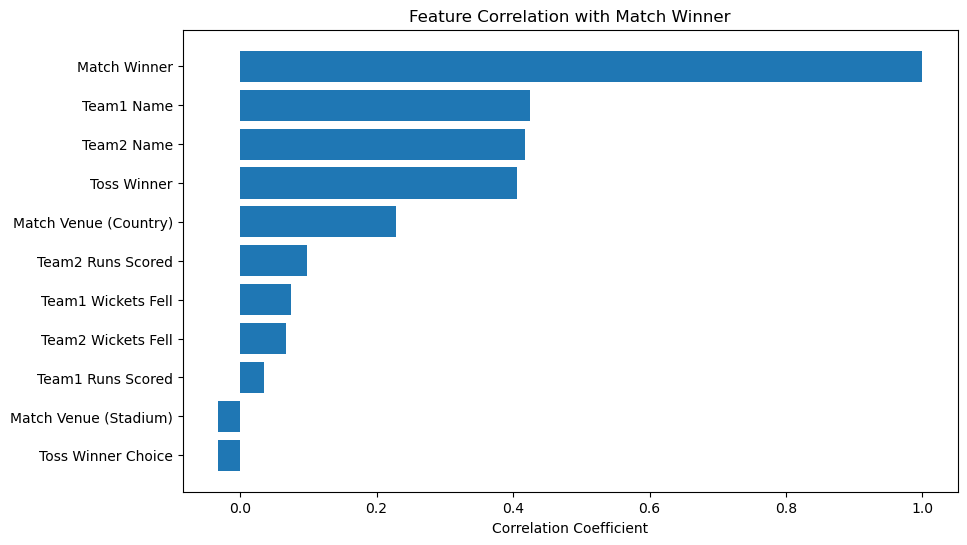

In [9]:
import matplotlib.pyplot as plt

correlation = data.corr(numeric_only=True)['Match Winner'].sort_values(ascending=False)
print(correlation)

# Plot using matplotlib only
plt.figure(figsize=(10,6))
plt.barh(correlation.index, correlation.values)
plt.title("Feature Correlation with Match Winner")
plt.xlabel("Correlation Coefficient")
plt.gca().invert_yaxis() 
plt.show()

# Drop low-correlation columns

In [10]:
columns_to_drop = [
    'Match Venue (Stadium)',
    'Toss Winner Choice',
    'Match Format'
]

data = data.drop(columns=columns_to_drop, axis=1)

# Check the remaining columns
data.columns

Index(['Team1 Name', 'Team2 Name', 'Match Venue (Country)', 'Toss Winner',
       'Match Winner', 'Team1 Runs Scored', 'Team1 Wickets Fell',
       'Team2 Runs Scored', 'Team2 Wickets Fell'],
      dtype='object')

# Separate features (X) and target (y)

In [11]:
X = data.drop(['Match Winner'], axis=1)
y = data['Match Winner']

# Train and test dataset

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create model dictionary to find the best model

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# train each models
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = {'Accuracy': acc, 'F1 Score': f1}

# Show comparison
results_df = pd.DataFrame(results).T
results_df.sort_values(by='Accuracy', ascending=False)

/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Accuracy,F1 Score
Gradient Boosting,0.703085,0.700879
Random Forest,0.591260,0.574465
SVM,0.123393,0.066911
Logistic Regression,0.089974,0.056994


# Select the best model

In [14]:
gradient_boost_model = models['Gradient Boosting']

# Try example encoded user input

In [15]:
new_match = {
    'Team1 Name': 4,   
    'Team2 Name': 44,  
    'Match Venue (Country)': 4,  
    'Toss Winner': 4   
}

# Convert to DataFrame
new_df = pd.DataFrame([new_match])

# Get the mean values for runs scored, wickets fell for each teams using stats by handle NaN values using Global averages
team1 = new_match['Team1 Name']
team2 = new_match['Team2 Name']


# --- Filter head-to-head matches ---
head_to_head = data[
    ((data['Team1 Name'] == team1) & (data['Team2 Name'] == team2)) |
    ((data['Team1 Name'] == team2) & (data['Team2 Name'] == team1))
].copy()

# Fallback if no direct matches found
if head_to_head.empty:
    print("⚠️ No direct head-to-head matches found. Using global averages.")
    head_to_head = data.copy()


# --- Compute averages for both teams ---
def get_mean_stat(data, t1, t2):
    """Compute mean runs and wickets based on historical data."""
    t1_as_team1 = data[(data['Team1 Name'] == t1) & (data['Team2 Name'] == t2)]
    t1_as_team2 = data[(data['Team1 Name'] == t2) & (data['Team2 Name'] == t1)]

    # Averages for Team 1
    t1_runs = pd.concat([t1_as_team1['Team1 Runs Scored'], t1_as_team2['Team2 Runs Scored']], ignore_index=True)
    t1_wickets = pd.concat([t1_as_team1['Team1 Wickets Fell'], t1_as_team2['Team2 Wickets Fell']], ignore_index=True)

    # Averages for Team 2
    t2_runs = pd.concat([t1_as_team1['Team2 Runs Scored'], t1_as_team2['Team1 Runs Scored']], ignore_index=True)
    t2_wickets = pd.concat([t1_as_team1['Team2 Wickets Fell'], t1_as_team2['Team1 Wickets Fell']], ignore_index=True)

    return (
        round(t1_runs.mean(), 2) if not t1_runs.empty else np.nan,
        round(t1_wickets.mean(), 2) if not t1_wickets.empty else np.nan,
        round(t2_runs.mean(), 2) if not t2_runs.empty else np.nan,
        round(t2_wickets.mean(), 2) if not t2_wickets.empty else np.nan
    )


# --- Calculate mean stats ---
t1_runs, t1_wickets, t2_runs, t2_wickets = get_mean_stat(head_to_head, team1, team2)

# Fill the calculated stats
new_df['Team1 Runs Scored'] = t1_runs
new_df['Team1 Wickets Fell'] = t1_wickets
new_df['Team2 Runs Scored'] = t2_runs
new_df['Team2 Wickets Fell'] = t2_wickets


# Columns that need to be filled
missing_features = ['Team1 Runs Scored', 'Team1 Wickets Fell',
                    'Team2 Runs Scored', 'Team2 Wickets Fell']

# Handle NaN (use global averages)
for feature in missing_features:
    if pd.isna(new_df.loc[0, feature]):
        new_df.loc[0, feature] = data[feature].mean()


print("\n📊 Head-to-Head or Global Averages Used:")
print(f"Team1 (encoded {team1}) Runs: {t1_runs}, Wickets: {t1_wickets}")
print(f"Team2 (encoded {team2}) Runs: {t2_runs}, Wickets: {t2_wickets}")


# Ensure same feature order as training
new_df = new_df[X.columns]

print("\n✅ Final Input for Prediction:")
print(new_df)

⚠️ No direct head-to-head matches found. Using global averages.

📊 Head-to-Head or Global Averages Used:
Team1 (encoded 4) Runs: nan, Wickets: nan
Team2 (encoded 44) Runs: nan, Wickets: nan

✅ Final Input for Prediction:
   Team1 Name  Team2 Name  Match Venue (Country)  Toss Winner  \
0           4          44                      4            4   

   Team1 Runs Scored  Team1 Wickets Fell  Team2 Runs Scored  \
0         146.972994            6.812886         124.095293   

   Team2 Wickets Fell  
0            5.920525  


# Prediction Probabilities

In [16]:
try:
    probabilities = gradient_boost_model.predict_proba(new_df)[0]
    classes = gradient_boost_model.classes_

    # Initialize default values
    team1_prob = team2_prob = tie_prob = 0.0

    for cls, prob in zip(classes, probabilities):
        if cls == team1:
            team1_prob = prob * 100
        elif cls == team2:
            team2_prob = prob * 100
        elif cls == 0:
            tie_prob = prob * 100  # 0 means tie/no result

    
    # Normalize (if tie/no result small, adjust for 100%)
    total = team1_prob + team2_prob + tie_prob
    if total > 0:
        team1_prob = round((team1_prob / total) * 100, 2)
        team2_prob = round((team2_prob / total) * 100, 2)
        tie_prob = round((tie_prob / total) * 100, 2)

    print("\n🏏 Predicted Winning Probabilities:")
    print(f"Team1 (Encoded {team1}) Winning Chance: {team1_prob}%")
    print(f"Team2 (Encoded {team2}) Winning Chance: {team2_prob}%")
    print(f"Tie/No Result Chance: {tie_prob}%")

except Exception as e:
    print(f"\n❌ Prediction failed: {e}")


🏏 Predicted Winning Probabilities:
Team1 (Encoded 4) Winning Chance: 9.18%
Team2 (Encoded 44) Winning Chance: 88.57%
Tie/No Result Chance: 2.25%
